# Filtro Final

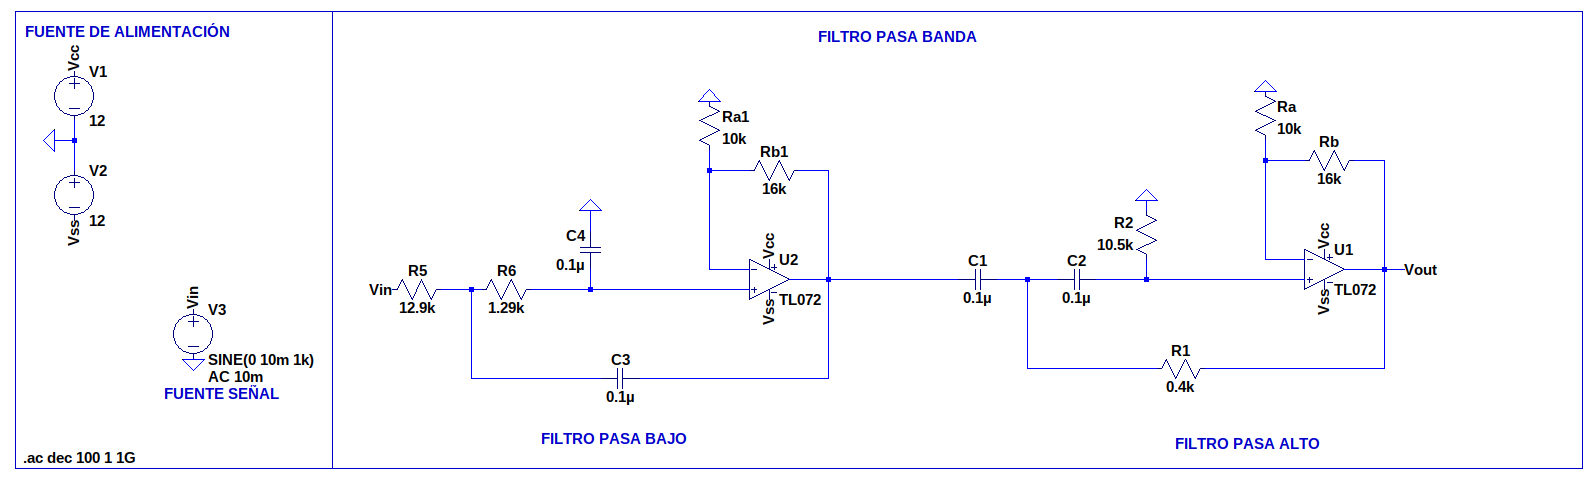


Pico: -51.36 dB @ 407.4 Hz


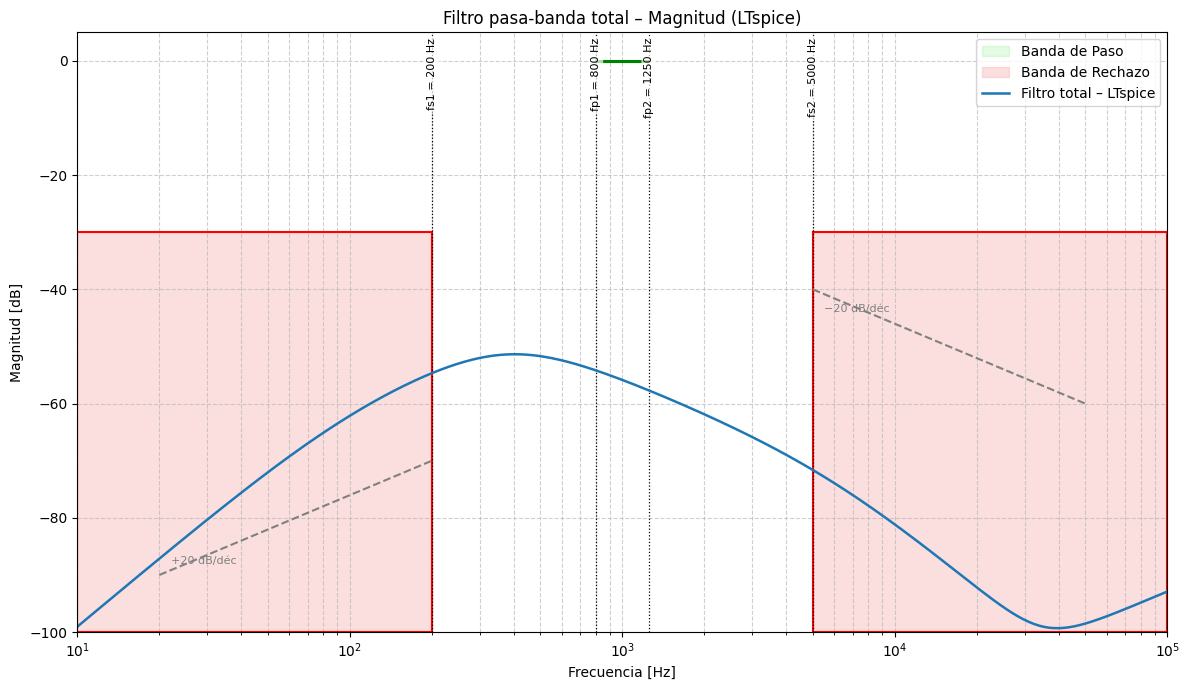

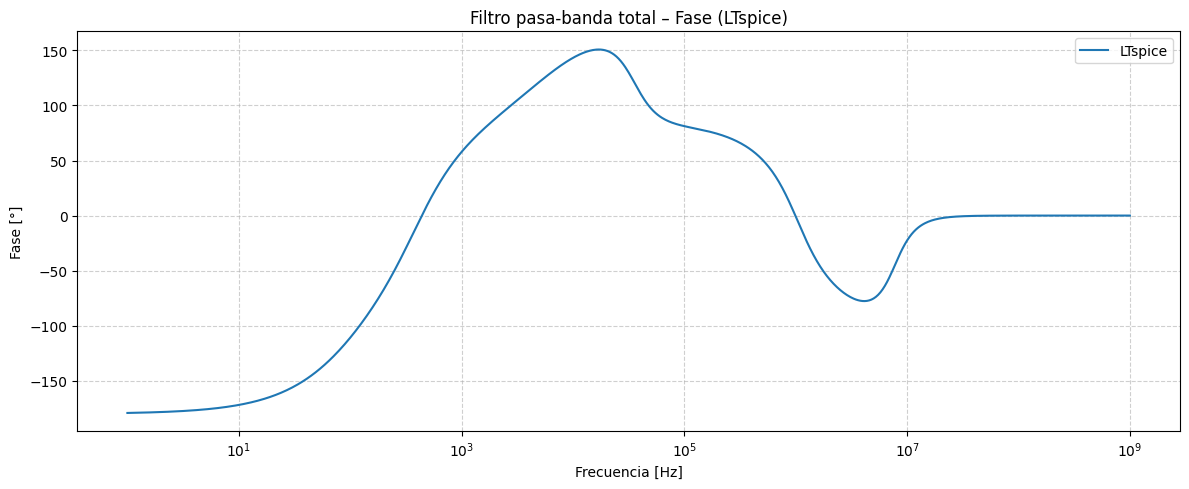

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# 1) LECTURA DEL ARCHIVO LTspice
# ======================================================

def load_ltspice_complex(filename):
    freq, re_v, im_v = [], [], []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            f_val = float(parts[0])
            re_str, im_str = parts[1].split(',')
            freq.append(f_val)
            re_v.append(float(re_str))
            im_v.append(float(im_str))

    freq = np.array(freq)
    v = np.array(re_v) + 1j*np.array(im_v)
    mag_db = 20*np.log10(np.abs(v))
    phase_deg = np.angle(v, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
# 2) FRECUENCIAS CARACTERÍSTICAS (TP4)
# ======================================================

fp = [800, 1250]       # Banda de paso
fs = [200, 5000]       # Banda de rechazo
Ap = 0.25
As = 30


# ======================================================
# 3) PLANTILLA + FRECUENCIAS CARACTERÍSTICAS
# ======================================================

def add_template(ax):
    y_min, y_max = -100, 5

    # --- Banda de paso ---
    ax.fill_between(fp, -Ap, 0, color='lightgreen', alpha=0.25, label='Banda de Paso')
    ax.plot([fp[0], fp[1], fp[1], fp[0], fp[0]], [-Ap, -Ap, 0, 0, -Ap], 'g')

    # --- Banda de rechazo izquierda ---
    ax.fill_between([10, fs[0]], y_min, -As, color='lightcoral', alpha=0.25)
    ax.plot([10, fs[0], fs[0], 10, 10], [-As, -As, y_min, y_min, -As], 'r')

    # --- Banda de rechazo derecha ---
    ax.fill_between([fs[1], 1e5], y_min, -As, color='lightcoral', alpha=0.25, label='Banda de Rechazo')
    ax.plot([fs[1], 1e5, 1e5, fs[1], fs[1]], [-As, -As, y_min, y_min, -As], 'r')

    # --- Frecuencias críticas (línea + etiqueta más prolija) ---
    f_marks = {
        fs[0]: "fs1 = 200 Hz",
        fp[0]: "fp1 = 800 Hz",
        fp[1]: "fp2 = 1250 Hz",
        fs[1]: "fs2 = 5000 Hz"
    }

    for f_val, label in f_marks.items():
        ax.axvline(f_val, color='k', linestyle=':', linewidth=0.9)
        ax.text(
            f_val, y_max - 1, label,
            rotation=90,
            va='top', ha='center',
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", ec="none", alpha=0.7)
        )

    # --- Líneas guía de pendiente ---
    # +20 dB/déc (subida)
    x1, x2 = 20, 200
    y1 = -90
    y2 = y1 + 20   # +20 dB/déc
    ax.plot([x1, x2], [y1, y2], color='gray', linestyle='--')
    ax.text(x1 * 1.1, y1 + 2, "+20 dB/déc", fontsize=8, color='gray')

    # -20 dB/déc (caída)
    x3, x4 = 5000, 50000
    y3 = -40
    y4 = y3 - 20   # -20 dB/déc
    ax.plot([x3, x4], [y3, y4], color='gray', linestyle='--')
    ax.text(x3 * 1.1, y3 - 4, "−20 dB/déc", fontsize=8, color='gray')

    # Ejes y grilla
    ax.set_xlim([10, 1e5])
    ax.set_ylim([y_min, y_max])
    ax.grid(which='both', ls='--', alpha=0.6)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Magnitud [dB]")



# ======================================================
# 4) CARGA DEL ARCHIVO
# ======================================================

filename = "filtro_pb_pa.txt"

freq, mag_db, phase_deg = load_ltspice_complex(filename)

idx_max = np.argmax(mag_db)
print(f"Pico: {mag_db[idx_max]:.2f} dB @ {freq[idx_max]:.1f} Hz")


# ======================================================
# 5) GRAFICAR – MAGNITUD + PENDIENTES + FRECUENCIAS
# ======================================================

plt.figure(figsize=(12,7))
ax1 = plt.gca()
add_template(ax1)

ax1.semilogx(freq, mag_db, label="Filtro total – LTspice",
             color="tab:blue", linewidth=1.8)

plt.title("Filtro pasa-banda total – Magnitud (LTspice)")
plt.legend()
plt.tight_layout()


# ======================================================
# 6) FASE
# ======================================================

plt.figure(figsize=(12,5))
plt.semilogx(freq, phase_deg, color="tab:blue", label="LTspice")
plt.grid(which='both', ls='--', alpha=0.6)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [°]")
plt.title("Filtro pasa-banda total – Fase (LTspice)")
plt.legend()
plt.tight_layout()

plt.show()


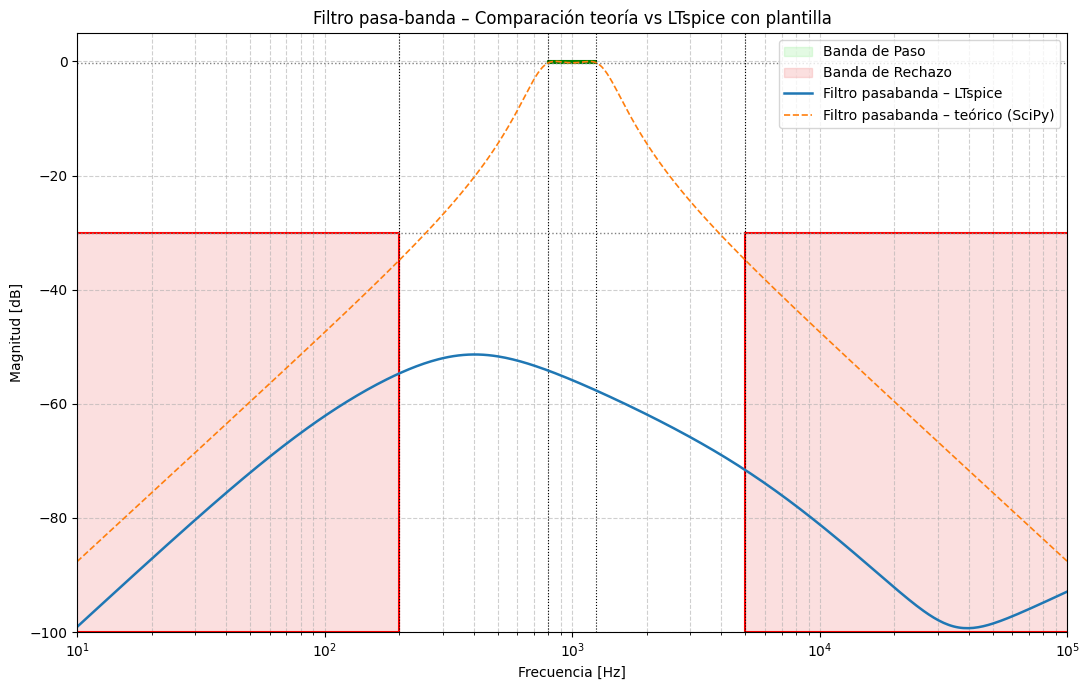

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20 * np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Parámetros de la plantilla del TP4
# ======================================================

fp = [800, 1250]      # banda de paso [Hz]
fs = [200, 5000]      # bandas de rechazo [Hz]
Ap = 0.25             # ripple máximo en BP [dB]
As = 30               # atenuación mínima en BR [dB]

Wp = 2 * np.pi * np.array(fp)
Ws = 2 * np.pi * np.array(fs)

# Filtro Chebyshev I teórico (banda)
N, Wn = signal.cheb1ord(Wp, Ws, Ap, As, analog=True)
b, a = signal.cheby1(N, Ap, Wn, btype='bandpass', analog=True, output='ba')


# ======================================================
#  Leer datos del filtro TOTAL desde LTspice
# ======================================================

filename = "filtro_pb_pa.txt"   # <-- poné acá el nombre de tu archivo
freq_meas, mag_meas_db, phase_meas_deg = load_ltspice_complex(filename)

# Respuesta teórica sobre las MISMAS frecuencias
w = 2 * np.pi * freq_meas
_, H_theo = signal.freqs(b, a, w)
mag_theo_db = 20 * np.log10(np.abs(H_theo))
phase_theo_deg = np.angle(H_theo, deg=True)


# ======================================================
#  Función auxiliar: dibujar plantilla
# ======================================================

def add_template(ax):
    y_min = -100
    y_max = 5

    # Banda de paso
    ax.fill_between([fp[0], fp[1]], -Ap, 0,
                    color='lightgreen', alpha=0.25, label='Banda de Paso')
    ax.plot([fp[0], fp[1], fp[1], fp[0], fp[0]],
            [-Ap, -Ap, 0, 0, -Ap],
            color='green', linewidth=1.5)

    # Banda de rechazo izquierda
    ax.fill_between([1, fs[0]], y_min, -As,
                    color='lightcoral', alpha=0.25)
    ax.plot([1, fs[0], fs[0], 1, 1],
            [-As, -As, y_min, y_min, -As],
            color='red', linewidth=1.5)

    # Banda de rechazo derecha
    ax.fill_between([fs[1], 1e6], y_min, -As,
                    color='lightcoral', alpha=0.25, label='Banda de Rechazo')
    ax.plot([fs[1], 1e6, 1e6, fs[1], fs[1]],
            [-As, -As, y_min, y_min, -As],
            color='red', linewidth=1.5)

    # Líneas de referencia
    ax.axhline(-Ap, color='gray', linestyle=':', linewidth=1)
    ax.axhline(-As, color='gray', linestyle=':', linewidth=1)

    for fcrit in [fs[0], fp[0], fp[1], fs[1]]:
        ax.axvline(fcrit, color='k', linestyle=':', linewidth=0.8)

    ax.set_xlim([10, 1e5])     # recortamos a 10 Hz – 100 kHz (ajustá si querés)
    ax.set_ylim([y_min, y_max])
    ax.grid(which='both', ls='--', alpha=0.6)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Magnitud [dB]")


# ======================================================
#  Gráfico FINAL: plantilla + teoría + LTspice
# ======================================================

plt.figure(figsize=(11, 7))
ax1 = plt.gca()
add_template(ax1)

# Filtro total simulado
ax1.semilogx(freq_meas, mag_meas_db,
             label="Filtro pasabanda – LTspice", color="tab:blue", linewidth=1.8)

# Filtro total teórico
ax1.semilogx(freq_meas, mag_theo_db,
             '--', label="Filtro pasabanda – teórico (SciPy)",
             color="tab:orange", linewidth=1.2)

plt.title("Filtro pasa-banda – Comparación teoría vs LTspice con plantilla")
plt.legend()
plt.tight_layout()
plt.show()


## Analiss de montecarlo de sensibilidad

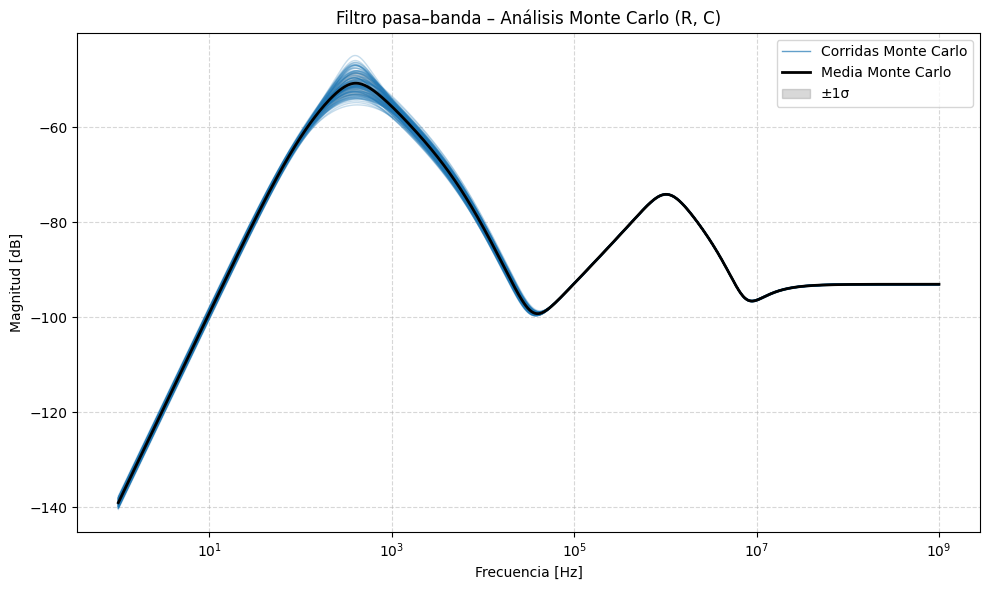

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Función para leer archivo LTspice con múltiples "Run"
# =====================================================
def load_mc_ltspice(filename):
    runs_freq = []
    runs_mag_db = []

    with open(filename, "r") as f:
        # cabecera "Freq.   V(vout)"
        next(f)

        freq = []
        vals = []

        for line in f:
            line = line.strip()
            if not line:
                continue

            # Cuando aparece "Step Information" empieza una nueva corrida
            if line.startswith("Step Information"):
                # guardo la corrida anterior (si ya había datos)
                if freq:
                    freq_arr = np.array(freq)
                    v_arr = np.array(vals, dtype=complex)
                    mag_db = 20 * np.log10(np.abs(v_arr))

                    runs_freq.append(freq_arr)
                    runs_mag_db.append(mag_db)

                    freq = []
                    vals = []
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            f_val = float(parts[0])
            re_str, im_str = parts[1].split(',')
            v_val = complex(float(re_str), float(im_str))

            freq.append(f_val)
            vals.append(v_val)

        # última corrida
        if freq:
            freq_arr = np.array(freq)
            v_arr = np.array(vals, dtype=complex)
            mag_db = 20 * np.log10(np.abs(v_arr))

            runs_freq.append(freq_arr)
            runs_mag_db.append(mag_db)

    return runs_freq, runs_mag_db


# =============================
#  Cargar y graficar Monte Carlo
# =============================
filename = "filtro_pb_pa_montecarlo.txt"    # cambia el nombre si hace falta

runs_freq, runs_mag_db = load_mc_ltspice(filename)

# uso el eje de frecuencias de la primera corrida
f = runs_freq[0]

plt.figure(figsize=(10, 6))

# todas las corridas en azul clarito
for i, mag_db in enumerate(runs_mag_db):
    alpha = 0.25 if i > 0 else 0.7
    label = "Corridas Monte Carlo" if i == 0 else None
    plt.semilogx(f, mag_db, color="tab:blue", alpha=alpha, linewidth=1, label=label)

# curva media y banda ±1σ para dar idea de dispersión
stack = np.vstack(runs_mag_db)   # shape: (Nruns, Nfreq)
mag_mean = stack.mean(axis=0)
mag_std  = stack.std(axis=0)

plt.semilogx(f, mag_mean, color="k", linewidth=2, label="Media Monte Carlo")
plt.fill_between(f, mag_mean - mag_std, mag_mean + mag_std,
                 color="gray", alpha=0.3, label="±1σ")

plt.grid(which="both", ls="--", alpha=0.5)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Filtro pasa–banda – Análisis Monte Carlo (R, C)")
plt.legend()
plt.tight_layout()
plt.show()
